# Cell types in the linear layer

Gridness is notebook 04's question. This one asks what *else* is in that layer
and whether it holds still, covering the paper's Fig. 1e, 1g and Extended Data
Fig. 3b:

| | paper |
|---|---|
| border cells (border score > 0.50) | 8.7% |
| conjunctive grid x head-direction cells | 14, 11% of the 129 grid units |
| grid scale | 28-115cm, mean 66cm |
| scale clustering | 3 clusters, 47/70/106cm, ratios ~1.5 |
| inter-trial stability | grid-like units stable, directional units not |

Nothing is implemented here: measures come from `scores.py`, aggregation from
`evaluate.py`, plots from `figures.py`.

Two caveats worth carrying into every number below.

**The bottleneck is a plain linear layer, so its activations are signed**, and
both the border score and the resultant vector assume a firing rate that cannot
be negative. Each unit's map is shifted by its own minimum first. That choice is
ours, not the paper's; see README "Known gaps" 3.

**Our width is 256, not the paper's 512.** The comparable figure for a 256-unit
bottleneck is its circular-arena result (21.9%), not the 25.2% headline.

In [1]:
import os
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

import numpy as np
import torch
import matplotlib.pyplot as plt

import evaluate
import figures
from config import Config
from dataset import build_dataloader
from scores import BORDER_BINS, BORDER_THRESHOLD, HD_THRESHOLD, score_units

CHECKPOINT = "data/checkpoints/baseline/checkpoint_epoch299.pt"   # 3e5 steps
CHECKPOINT_EARLY = "data/checkpoints/baseline/checkpoint_epoch200.pt"  # 2e5 steps
N_TRAJECTORIES = 4000
NBINS = 32  # paper's Methods, for gridness; the border score rebins to 20

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cfg = Config()
print(device, "|", ROOT)

cuda | /home/user/workspace(junoLee)/grid-cells-torch


## Score the layer once

Same inference and gridness/head-direction pass as notebook 04 — repeated here
so this notebook stands alone, and cheap next to the analyses below.

In [2]:
model, _, epoch, place, hd = evaluate.load_models(cfg, CHECKPOINT, device)

loader = build_dataloader("data/shards", shard_indices=None,
                          batch_size=cfg.train.minibatch_size, shuffle=True)
batches, n_traj = evaluate.collect_batches(loader, N_TRAJECTORIES)
true_pos = np.concatenate([b["target_pos"].numpy() for b in batches], axis=0)
headings = np.concatenate([b["target_hd"].numpy() for b in batches]).reshape(-1)
xy = true_pos.reshape(-1, 2)

_, bottleneck_acts, _ = evaluate.run_model(
    model, batches, place, hd, device, want_activations=True)
acts = bottleneck_acts.reshape(-1, bottleneck_acts.shape[-1])

scorer = evaluate.build_scorer(cfg, NBINS)
scores_60, ratemaps, sacs, mask_params = score_units(scorer, xy, acts)
hd_tuning, resultants = evaluate.score_directional(headings, acts)

print(f"epoch {epoch} | {n_traj} trajectories | {acts.shape[1]} bottleneck units")
evaluate.report_gridness("bottleneck", scores_60)
evaluate.report_directional("bottleneck", resultants)

epoch 299 | 4000 trajectories | 256 bottleneck units
  bottleneck: mean score_60=-0.103, max=0.955, score_60>0.37 (paper's threshold) = 20/256 (7.8%)
  bottleneck: mean resultant=0.428, max=0.667, >0.47 (paper's threshold) = 109/256 (42.6%)


109

## Border cells — Suppl. eq. (8)

`b_s = max_i (b_i - c)/(b_i + c)` over the four walls, `d_b = 3`, on **20x20**
bins. The paper uses a different binning here from the 32x32 it uses for
gridness, in the same paragraph, so this rebins rather than reusing the maps
above.

In [3]:
border = evaluate.score_borders(cfg, xy, acts, nbins=BORDER_BINS)
evaluate.report_border("bottleneck", border)

  bottleneck: mean border=0.129, max=0.712, >0.5 (paper's threshold) = 13/256 (5.1%)   [paper: 8.7%]


13

## Conjunctive cells — Fig. 1f,g

Units above both cutoffs at once. The paper's population is 14 units, 11% of
its 129 grid cells.

  bottleneck: 8 conjunctive (grid AND directional) = 40.0% of the 20 grid-like units   [paper: 14, 11% of 129]


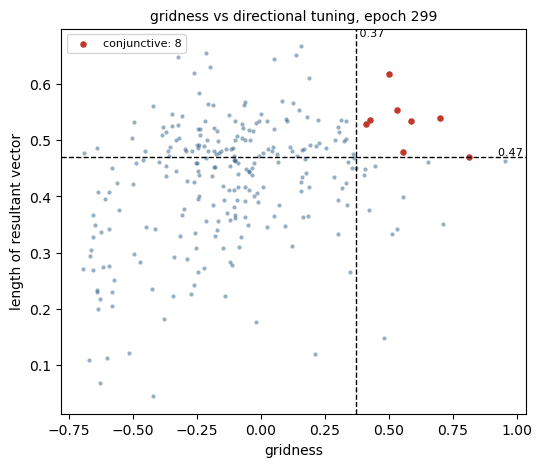

In [4]:
n_conj = evaluate.report_conjunctive("bottleneck", scores_60, resultants)

fig, ax = plt.subplots(figsize=(6, 5))
figures.plot_gridness_vs_directional(scores_60, resultants,
                                     evaluate.GRIDNESS_THRESHOLD, HD_THRESHOLD, ax=ax)
ax.set_title(f"gridness vs directional tuning, epoch {epoch}", fontsize=10)
plt.show()

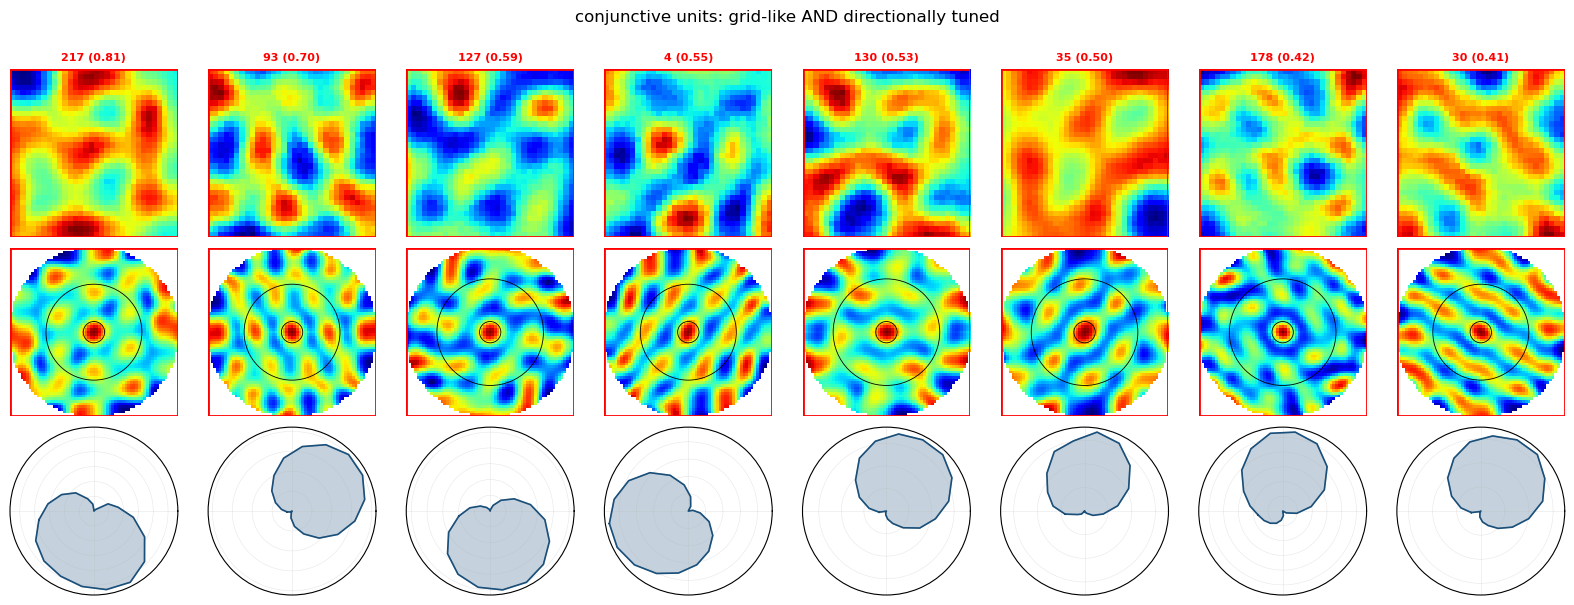

In [5]:
# The conjunctive units themselves, in Fig. 1d layout.
conj = np.flatnonzero((scores_60 > evaluate.GRIDNESS_THRESHOLD) & (resultants > HD_THRESHOLD))
if len(conj):
    order = conj[np.argsort(-scores_60[conj])][:8]
    fig = figures.plot_unit_grid(
        ratemaps, sacs, mask_params, scores_60, NBINS,
        indices=order, cols=len(order), threshold=evaluate.GRIDNESS_THRESHOLD,
        hd_tuning=hd_tuning, panel_size=2.0,
        title="conjunctive units: grid-like AND directionally tuned")
    plt.show()
else:
    print("no conjunctive units at this checkpoint")

## Grid scale and its clustering — Fig. 1e

Scale is the median distance of the six SAC maxima nearest the centre, the
central peak excluded. Measured only for grid-like units, as the paper does
("Assessment of grid scale was limited to units determined to be grid-like").

Then two independent tests of whether those scales cluster: the discreteness
measure against a jittered null (500 shuffles), and a 1-8 component Gaussian
mixture selected by BIC. The claim that transfers across arenas is the **ratio**
between neighbouring clusters (~1.5), not the absolute scales.

In [6]:
grid_like = scores_60 > evaluate.GRIDNESS_THRESHOLD
scales = evaluate.grid_scales(sacs, cfg, NBINS, grid_like)
evaluate.report_grid_scales("bottleneck", scales)

k, means, bics, ratios, obs, null, p = evaluate.report_scale_clustering(
    "bottleneck", scales, n_shuffles=500, seed=cfg.train.seed)

  bottleneck: 16 scales, range 90-124cm, mean 108cm   [paper: 28-115cm, mean 66cm]
  bottleneck: UNDERPOWERED -- 16 scales against the paper's 129. Both lines below are reported for completeness, not as findings: a mixture over this few points fits noise, and the shuffle test has little power to reject anything.


  bottleneck: discreteness 0.80 vs null 1.01+/-0.20, p=0.9202   [paper: p<0.002]
  bottleneck: BIC picks 1 cluster(s) at 108cm, ratios []   [paper: 3 at 47/70/106cm, ~1.5]


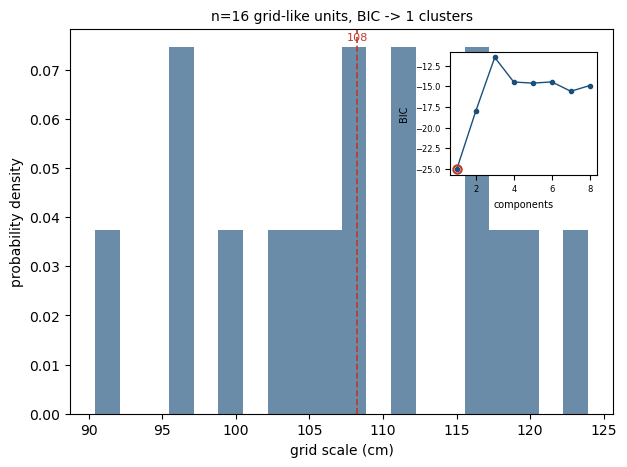

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
figures.plot_scale_distribution(scales, means, bics, ax=ax)
plt.show()

## Inter-trial stability — Ext. Data Fig. 3b

Bin-wise Pearson correlation between each unit's ratemap at 2e5 and 3e5
training steps, unvisited bins excluded. Both checkpoints are scored on the
**same** trajectories, so the correlation reflects representational drift and
not a different sample of the arena.

The paper's finding is a dissociation: grid-like units keep their map, whereas
directionally modulated units do not.

epoch 200 vs 299
  bottleneck: all units mean r=0.895
    grid-like    n=20   mean r=0.866
    directional  n=109  mean r=0.874
  [paper: grid-like units highly stable, directional units not]


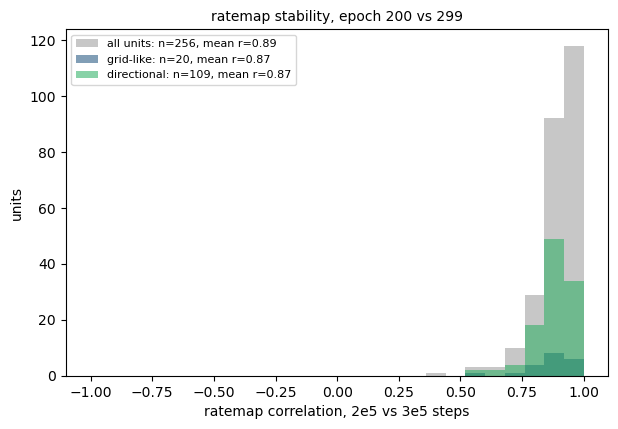

In [8]:
rm_late, ep_late = evaluate.layer_ratemaps(cfg, CHECKPOINT, batches, device, NBINS)
rm_early, ep_early = evaluate.layer_ratemaps(cfg, CHECKPOINT_EARLY, batches, device, NBINS)
stab = evaluate.stability(rm_early, rm_late)
print(f"epoch {ep_early} vs {ep_late}")
evaluate.report_stability("bottleneck", stab, scores_60, resultants)

fig, ax = plt.subplots(figsize=(7, 4.5))
figures.plot_stability(stab, scores_60, resultants,
                       evaluate.GRIDNESS_THRESHOLD, HD_THRESHOLD, ax=ax)
ax.set_title(f"ratemap stability, epoch {ep_early} vs {ep_late}", fontsize=10)
plt.show()

## Save

One figure, the four panels together, into `results/<run>/`.

saved /home/user/workspace(junoLee)/grid-cells-torch/results/baseline/cell_types_epoch299.png


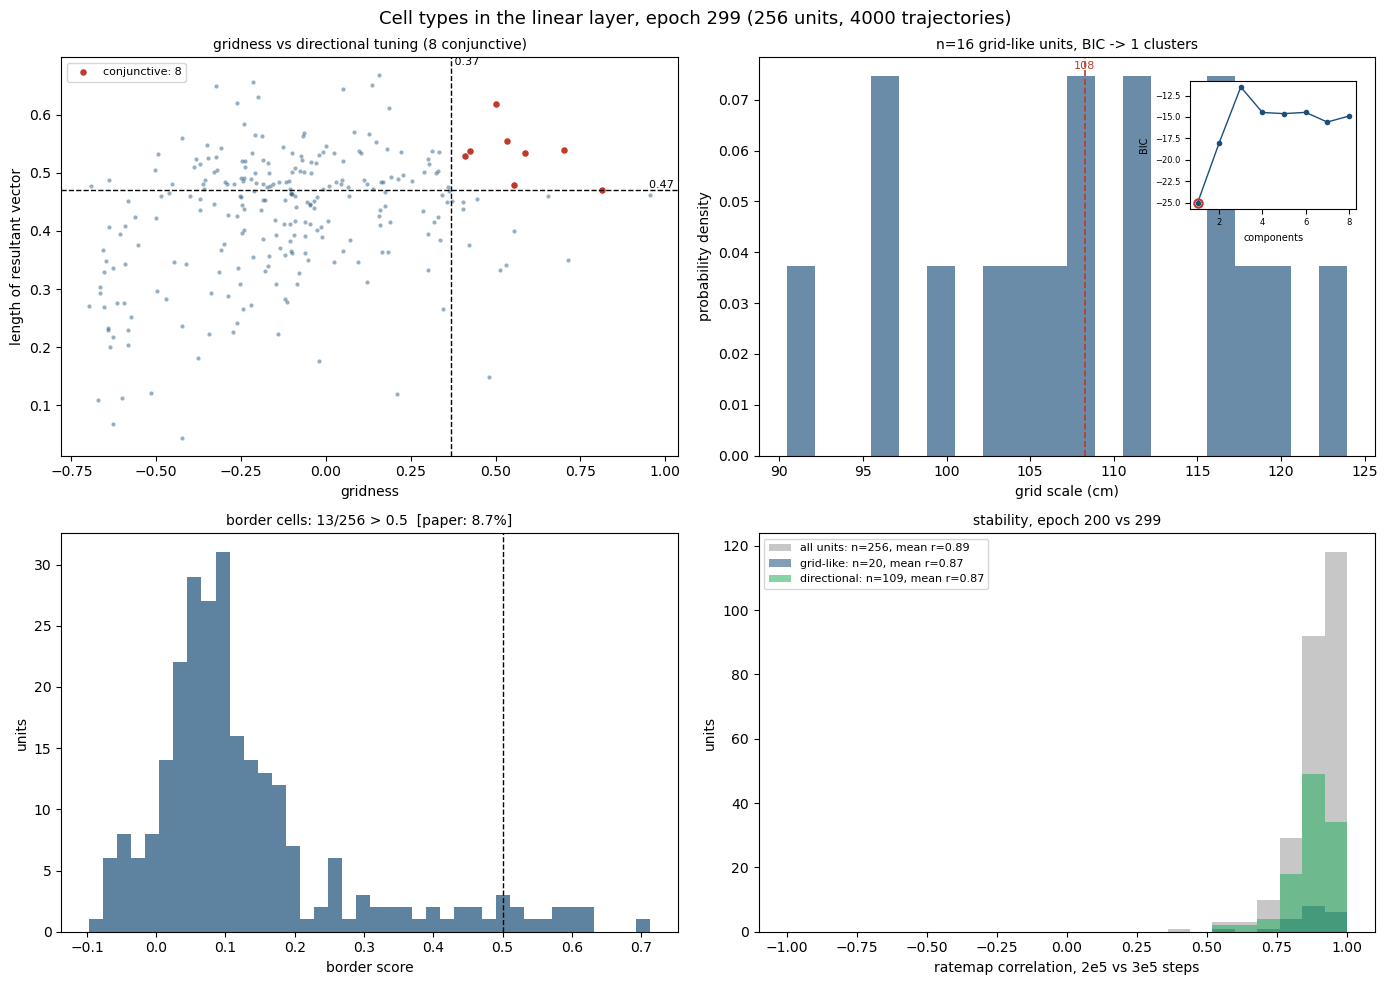

In [9]:
OUT_DIR = Path(evaluate.default_out_dir(CHECKPOINT))
OUT_DIR.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
figures.plot_gridness_vs_directional(scores_60, resultants,
                                     evaluate.GRIDNESS_THRESHOLD, HD_THRESHOLD, ax=axes[0, 0])
axes[0, 0].set_title(f"gridness vs directional tuning ({n_conj} conjunctive)", fontsize=10)
figures.plot_scale_distribution(scales, means, bics, ax=axes[0, 1])
axes[1, 0].hist(border, bins=40, color="#1a4f7a", alpha=0.7)
axes[1, 0].axvline(BORDER_THRESHOLD, color="k", ls="--", lw=1)
axes[1, 0].set_xlabel("border score"); axes[1, 0].set_ylabel("units")
axes[1, 0].set_title(f"border cells: {int((border > BORDER_THRESHOLD).sum())}/"
                     f"{len(border)} > {BORDER_THRESHOLD}  [paper: 8.7%]", fontsize=10)
figures.plot_stability(stab, scores_60, resultants,
                       evaluate.GRIDNESS_THRESHOLD, HD_THRESHOLD, ax=axes[1, 1])
axes[1, 1].set_title(f"stability, epoch {ep_early} vs {ep_late}", fontsize=10)
fig.suptitle(f"Cell types in the linear layer, epoch {epoch} "
             f"({acts.shape[1]} units, {n_traj} trajectories)", fontsize=13)
fig.tight_layout()

path = OUT_DIR / f"cell_types_epoch{epoch}.png"
fig.savefig(path, dpi=130, bbox_inches="tight")
print("saved", path)
plt.show()